# 04. 特徴量の相関分析 (Feature Correlation)

このノートブックでは、特徴量間の相関と目的変数との関係を分析します。

## 目次
1. セットアップ
2. 特徴量データの取得
3. 相関行列の分析
4. 目的変数との相関
5. 多重共線性の確認
6. 特徴量の重要度示唆

## 1. セットアップ

In [1]:
# 必要なライブラリのインポート
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')

# フォントキャッシュを再構築して日本語フォントを認識させる
font_manager._load_fontmanager(try_read_cache=False)

# プロット設定（スタイルを先に適用）
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 日本語フォント設定（スタイル適用後に設定することが重要）
plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

# seabornのフォント設定も上書き
sns.set(font='IPAexGothic')

# 表示設定
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# 環境変数の読み込み
load_dotenv()
PROJECT_ID = os.environ.get('GCP_PROJECT_ID')
client = bigquery.Client(project=PROJECT_ID)

print(f'Python: {sys.executable}')
print(f'Matplotlib font: {plt.rcParams["font.family"]}')
print(f'Project ID: {PROJECT_ID}')
print('Setup complete!')

/Users/michika_maruyama/Desktop/keiba_prediction/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/michika_maruyama/Desktop/keiba_prediction/venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/michika_maruyama/Desktop/keiba_prediction/venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: 
    You are using a Python version 3.9 past its end of life. Google will update
    google-auth with critical bug fixes on a best-effort basis,

Python: /Users/michika_maruyama/Desktop/keiba_prediction/venv/bin/python
Matplotlib font: ['IPAexGothic']
Project ID: keiba-prediction-1768734113
Setup complete!


## 2. 特徴量データの取得

In [2]:
# 特徴量テーブルからデータを取得
# features.training_dataが存在する場合はそれを使用、なければraw dataから構築

try:
    # features.training_dataテーブルを確認
    query_features = f"""
    SELECT *
    FROM `{PROJECT_ID}.features.training_data`
    LIMIT 10000
    """
    df_features = client.query(query_features).to_dataframe()
    print(f'features.training_dataからデータ取得: {len(df_features)}件')
    data_source = 'features'
except Exception as e:
    print(f'features.training_dataが存在しないか、エラー: {e}')
    print('raw dataからサンプルデータを構築します...')
    
    # raw dataから基本的な特徴量を構築
    query_raw = f"""
    SELECT 
        hr.race_id,
        hr.horse_id,
        hr.horse_number,
        hr.bracket_number,
        hr.base_odds,
        hr.base_popularity,
        hr.weight_carried,
        hr.horse_weight,
        hr.horse_weight_diff,
        hr.idm,
        hr.jockey_index,
        hr.info_index,
        hr.total_index,
        hr.running_style,
        hr.distance_aptitude,
        hr.last_3f_time,
        hr.corner_position_4,
        hr.goal_position,
        ri.distance,
        ri.num_horses
    FROM `{PROJECT_ID}.raw.horse_results` hr
    JOIN `{PROJECT_ID}.raw.race_info` ri ON hr.race_id = ri.race_id
    WHERE hr.goal_position IS NOT NULL AND hr.goal_position > 0
    LIMIT 20000
    """
    df_features = client.query(query_raw).to_dataframe()
    print(f'raw dataからデータ取得: {len(df_features)}件')
    data_source = 'raw'

print(f'\nカラム数: {len(df_features.columns)}')
print(f'\nカラム一覧:')
print(df_features.columns.tolist())

features.training_dataからデータ取得: 10000件

カラム数: 41

カラム一覧:
['race_id', 'horse_id', 'race_date', 'target_place', 'finish_position', 'venue_code', 'race_number', 'course_type', 'distance', 'track_condition', 'num_horses', 'bracket_number', 'horse_number', 'weight', 'past_3_avg_position', 'past_5_avg_position', 'past_10_avg_position', 'past_3_avg_last3f', 'past_5_avg_last3f', 'turf_win_rate', 'dirt_win_rate', 'distance_category_win_rate', 'venue_win_rate', 'heavy_track_win_rate', 'jockey_id', 'jockey_win_rate', 'jockey_venue_win_rate', 'trainer_id', 'trainer_win_rate', 'jockey_te_place', 'trainer_te_place', 'sire_te_place', 'dam_sire_te_place', 'weight_rank', 'ability_rank', 'last3f_rank', 'front_runner_count', 'expected_pace_score', 'odds_yesterday', 'odds_today', 'created_at']


In [3]:
# データの概要
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   race_id                     10000 non-null  object             
 1   horse_id                    10000 non-null  object             
 2   race_date                   10000 non-null  dbdate             
 3   target_place                10000 non-null  boolean            
 4   finish_position             10000 non-null  Int64              
 5   venue_code                  869 non-null    object             
 6   race_number                 869 non-null    Int64              
 7   course_type                 10000 non-null  object             
 8   distance                    10000 non-null  Int64              
 9   track_condition             10000 non-null  object             
 10  num_horses                  10000 non-null  Int64          

In [4]:
# 数値カラムのみを抽出
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
print(f'数値カラム数: {len(numeric_cols)}')
print(f'\n数値カラム:')
print(numeric_cols)

数値カラム数: 31

数値カラム:
['finish_position', 'race_number', 'distance', 'num_horses', 'bracket_number', 'horse_number', 'weight', 'past_3_avg_position', 'past_5_avg_position', 'past_10_avg_position', 'past_3_avg_last3f', 'past_5_avg_last3f', 'turf_win_rate', 'dirt_win_rate', 'distance_category_win_rate', 'venue_win_rate', 'heavy_track_win_rate', 'jockey_win_rate', 'jockey_venue_win_rate', 'trainer_win_rate', 'jockey_te_place', 'trainer_te_place', 'sire_te_place', 'dam_sire_te_place', 'weight_rank', 'ability_rank', 'last3f_rank', 'front_runner_count', 'expected_pace_score', 'odds_yesterday', 'odds_today']


In [5]:
# 目的変数を追加（3着以内フラグ）
if 'goal_position' in df_features.columns:
    df_features['target_place'] = (df_features['goal_position'] <= 3).astype(int)
elif 'finish_position' in df_features.columns:
    df_features['target_place'] = (df_features['finish_position'] <= 3).astype(int)

print(f'目的変数（3着以内）の分布:')
print(df_features['target_place'].value_counts(normalize=True))

目的変数（3着以内）の分布:
target_place
0   0.780
1   0.220
Name: proportion, dtype: float64


## 3. 相関行列の分析

In [6]:
# 欠損値の少ないカラムのみを選択
numeric_df = df_features[numeric_cols].copy()
missing_pct = numeric_df.isnull().mean()
valid_cols = missing_pct[missing_pct < 0.3].index.tolist()

print(f'欠損率30%未満のカラム数: {len(valid_cols)}')

欠損率30%未満のカラム数: 5


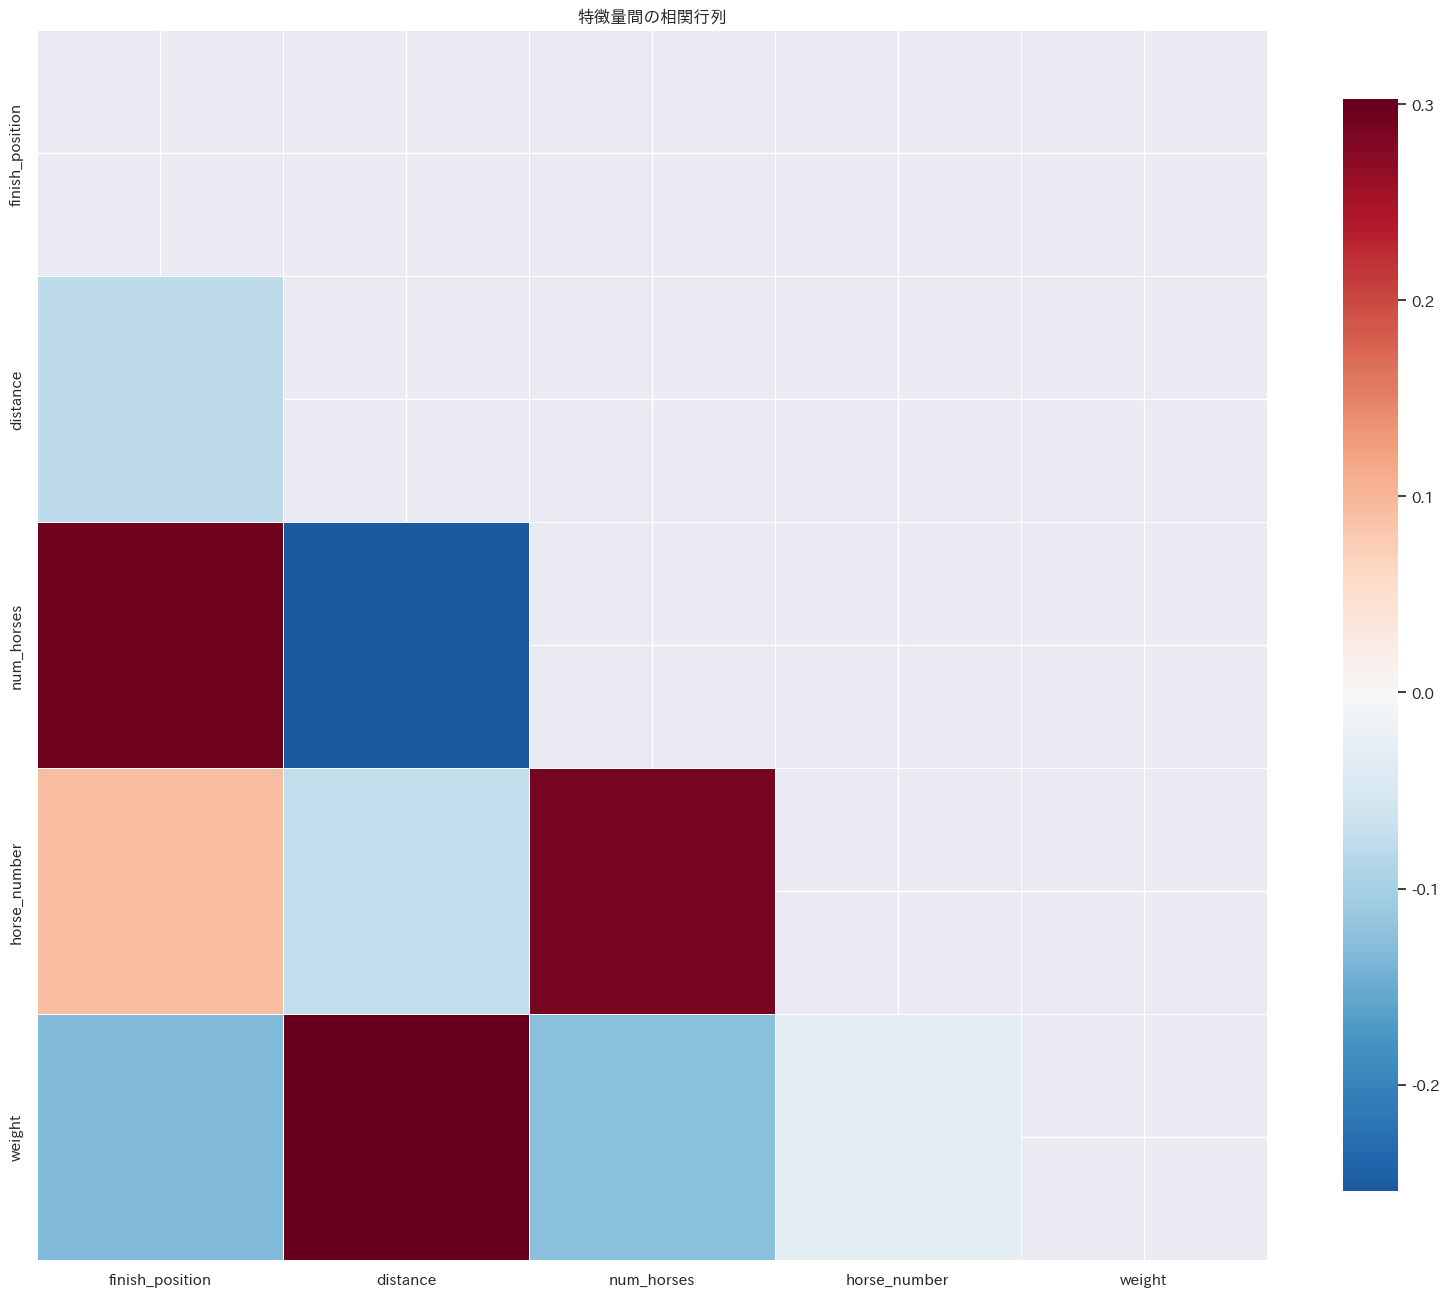

In [7]:
# 相関行列を計算
corr_matrix = df_features[valid_cols].corr()

# 相関行列のヒートマップ
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('特徴量間の相関行列')
plt.tight_layout()
plt.show()

In [8]:
# 高い相関を持つ特徴量ペアを抽出
def find_high_correlations(corr_matrix, threshold=0.7):
    """高相関の特徴量ペアを抽出"""
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)

high_corr = find_high_correlations(corr_matrix, threshold=0.7)
print(f'=== 相関係数0.7以上のペア ({len(high_corr)}組) ===')
high_corr

KeyError: 'correlation'

## 4. 目的変数との相関

In [9]:
# 目的変数（3着以内フラグ）との相関
if 'target_place' in df_features.columns:
    target_corr = df_features[valid_cols + ['target_place']].corr()['target_place'].drop('target_place')
    target_corr_sorted = target_corr.abs().sort_values(ascending=False)
    
    print('=== 目的変数（3着以内）との相関（絶対値順） ===')
    print(target_corr_sorted.head(20))

=== 目的変数（3着以内）との相関（絶対値順） ===
finish_position   0.684
num_horses        0.122
weight            0.079
horse_number      0.031
distance          0.031
Name: target_place, dtype: float64


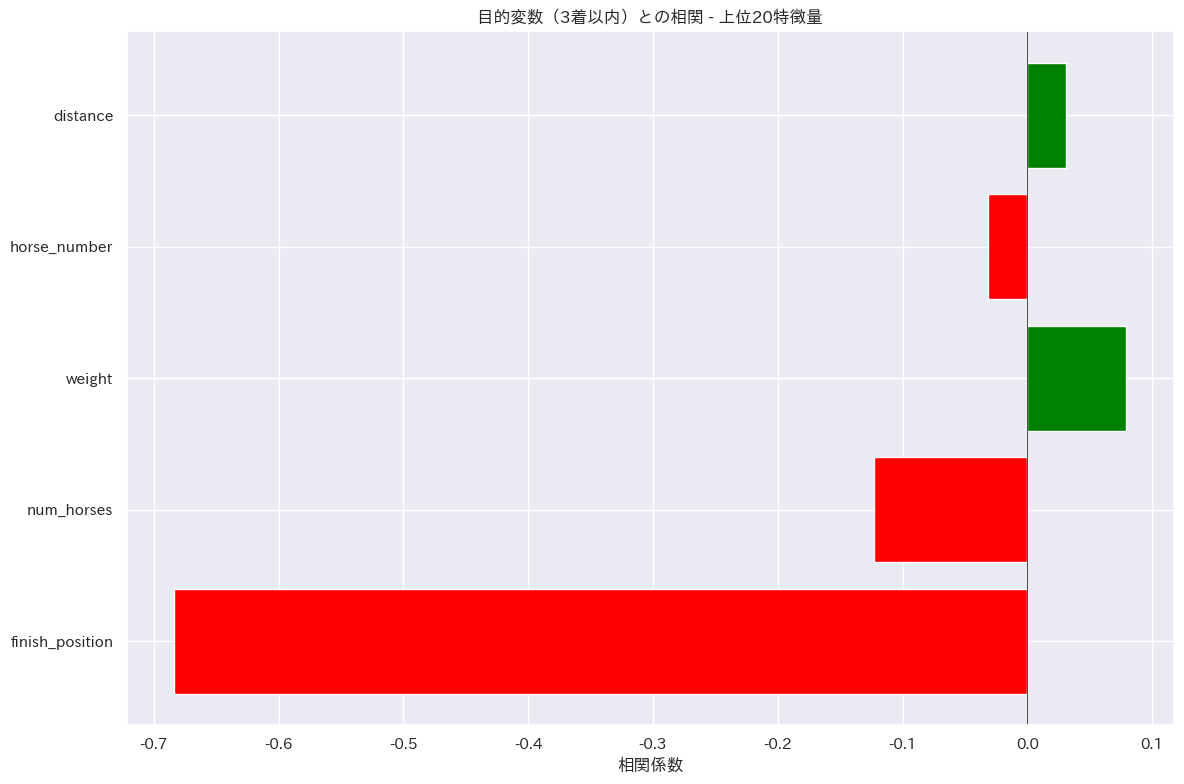

In [10]:
# 目的変数との相関を可視化
if 'target_place' in df_features.columns:
    # 上位20の特徴量
    top_features = target_corr_sorted.head(20)
    
    plt.figure(figsize=(12, 8))
    colors = ['green' if target_corr[f] > 0 else 'red' for f in top_features.index]
    plt.barh(top_features.index, target_corr[top_features.index], color=colors)
    plt.xlabel('相関係数')
    plt.title('目的変数（3着以内）との相関 - 上位20特徴量')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

In [11]:
# 着順との相関も確認
position_col = 'goal_position' if 'goal_position' in df_features.columns else 'finish_position'

if position_col in df_features.columns:
    position_corr = df_features[valid_cols + [position_col]].corr()[position_col].drop(position_col)
    position_corr_sorted = position_corr.abs().sort_values(ascending=False)
    
    print('=== 着順との相関（絶対値順） ===')
    print(position_corr_sorted.head(20))

TypeError: sort_values() missing 1 required positional argument: 'by'

## 5. 多重共線性の確認

In [12]:
# VIF（分散膨張係数）の計算
from sklearn.preprocessing import StandardScaler

def calculate_vif(df, features):
    """VIFを計算（簡易版）"""
    vif_data = []
    
    # 欠損値を除去
    df_clean = df[features].dropna()
    
    if len(df_clean) < len(features) * 10:
        print('Warning: サンプルサイズが小さすぎます')
        return pd.DataFrame()
    
    # 標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean)
    X_scaled = pd.DataFrame(X_scaled, columns=features)
    
    # 相関行列から近似的にVIFを計算
    corr = X_scaled.corr()
    
    for i, feature in enumerate(features):
        # R^2の近似計算
        other_features = [f for f in features if f != feature]
        r_squared = corr.loc[feature, other_features].abs().max() ** 2
        
        if r_squared < 1:
            vif = 1 / (1 - r_squared)
        else:
            vif = np.inf
        
        vif_data.append({'feature': feature, 'VIF': vif})
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# 主要な特徴量でVIFを計算
important_features = target_corr_sorted.head(15).index.tolist() if 'target_place' in df_features.columns else valid_cols[:15]

vif_df = calculate_vif(df_features, important_features)
print('=== VIF（分散膨張係数）===')
print('VIF > 10: 多重共線性の問題あり')
print('VIF > 5: 注意が必要')
print('')
vif_df

=== VIF（分散膨張係数）===
VIF > 10: 多重共線性の問題あり
VIF > 5: 注意が必要



,feature,VIF
2,weight,1.101
4,distance,1.101
0,finish_position,1.093
1,num_horses,1.093
3,horse_number,1.091


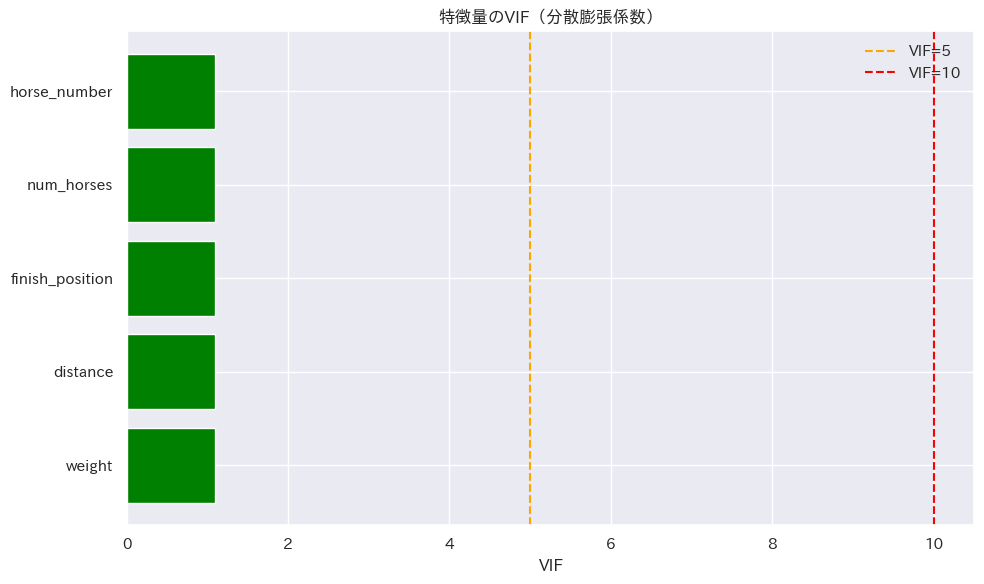

In [13]:
# VIFの可視化
if len(vif_df) > 0:
    plt.figure(figsize=(10, 6))
    colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in vif_df['VIF']]
    plt.barh(vif_df['feature'], vif_df['VIF'], color=colors)
    plt.axvline(x=5, color='orange', linestyle='--', label='VIF=5')
    plt.axvline(x=10, color='red', linestyle='--', label='VIF=10')
    plt.xlabel('VIF')
    plt.title('特徴量のVIF（分散膨張係数）')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. 特徴量の重要度示唆

In [14]:
# 特徴量の選択基準をまとめ
print('=== 特徴量選択の指針 ===')
print('')

if 'target_place' in df_features.columns:
    # 目的変数との相関が高い特徴量
    print('■ 目的変数との相関が高い特徴量（|r| > 0.1）:')
    high_target_corr = target_corr_sorted[target_corr_sorted > 0.1]
    for feat in high_target_corr.index[:10]:
        print(f'  - {feat}: {target_corr[feat]:.3f}')
    print('')

# 高い相関を持つ特徴量ペア（片方を除去する候補）
if len(high_corr) > 0:
    print('■ 多重共線性の懸念があるペア（|r| > 0.7）:')
    for _, row in high_corr.head(10).iterrows():
        print(f'  - {row["feature_1"]} ⇔ {row["feature_2"]}: {row["correlation"]:.3f}')
    print('')

# VIFが高い特徴量
if len(vif_df) > 0:
    high_vif = vif_df[vif_df['VIF'] > 5]
    if len(high_vif) > 0:
        print('■ VIFが高い特徴量（注意が必要）:')
        for _, row in high_vif.iterrows():
            print(f'  - {row["feature"]}: VIF={row["VIF"]:.1f}')

=== 特徴量選択の指針 ===

■ 目的変数との相関が高い特徴量（|r| > 0.1）:
  - finish_position: -0.684
  - num_horses: -0.122



NameError: name 'high_corr' is not defined

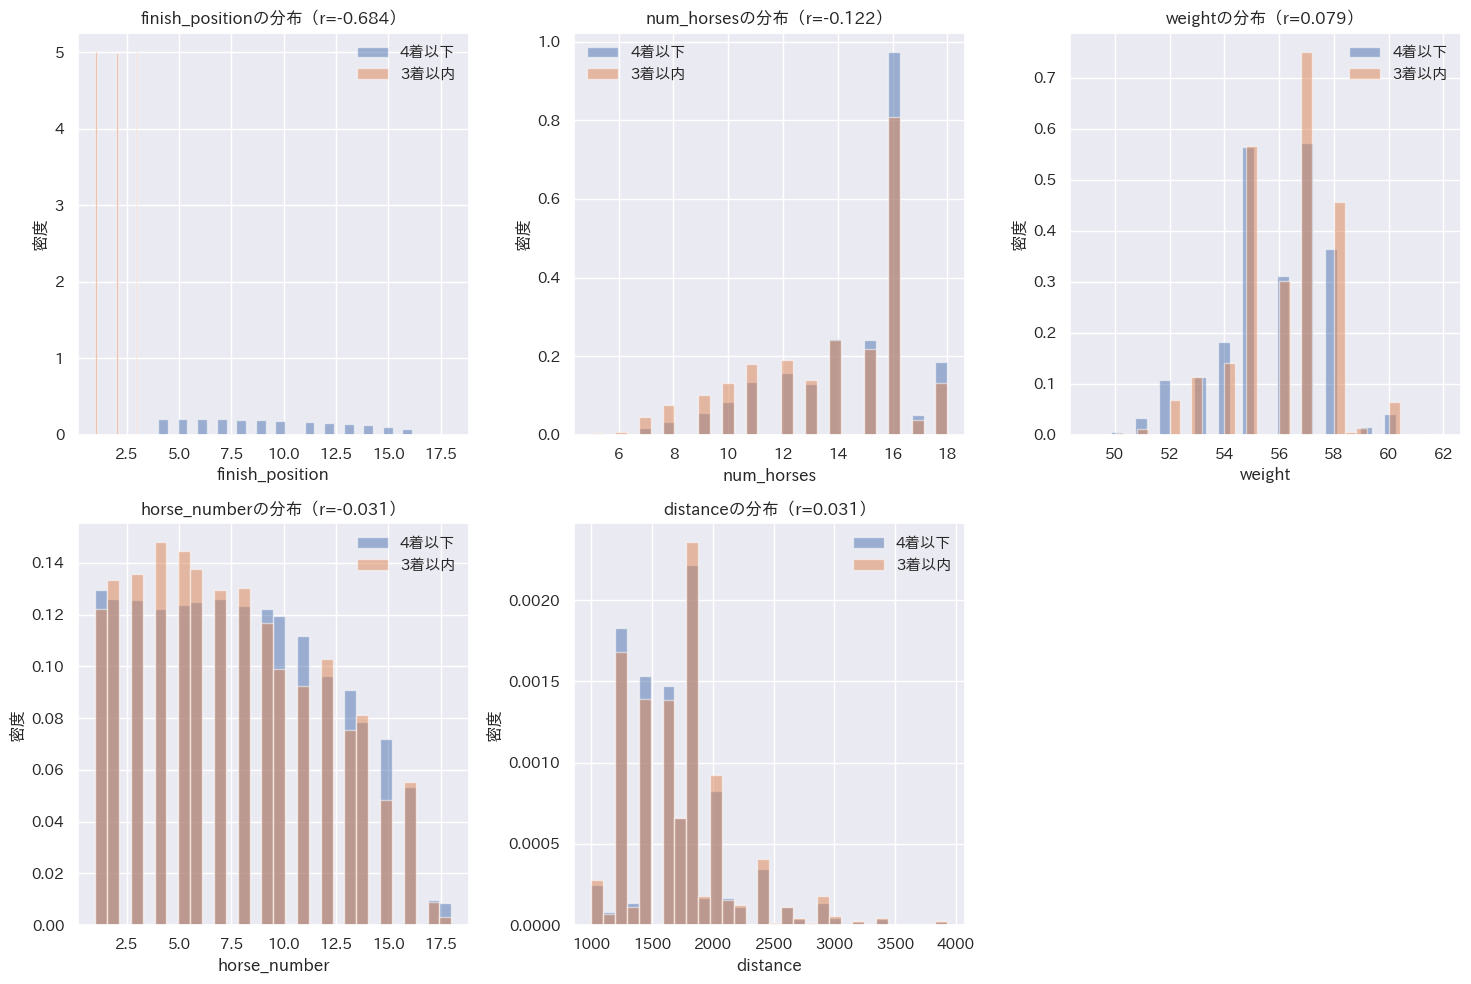

In [15]:
# 特徴量の分布を確認（上位5特徴量）
if 'target_place' in df_features.columns:
    top_5_features = target_corr_sorted.head(5).index.tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, feat in enumerate(top_5_features):
        if feat in df_features.columns:
            # 3着以内とそれ以外で分けてヒストグラム
            place_data = df_features[df_features['target_place'] == 1][feat].dropna()
            other_data = df_features[df_features['target_place'] == 0][feat].dropna()
            
            axes[i].hist(other_data, bins=30, alpha=0.5, label='4着以下', density=True)
            axes[i].hist(place_data, bins=30, alpha=0.5, label='3着以内', density=True)
            axes[i].set_xlabel(feat)
            axes[i].set_ylabel('密度')
            axes[i].set_title(f'{feat}の分布（r={target_corr[feat]:.3f}）')
            axes[i].legend()
    
    # 最後のサブプロットは非表示
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.show()

## まとめ

このノートブックでは以下の分析を行いました：

1. **特徴量データの確認**: 数値カラムの抽出と欠損値の確認
2. **相関行列の分析**: 特徴量間の相関を可視化
3. **目的変数との相関**: 3着以内フラグとの相関が高い特徴量を特定
4. **多重共線性の確認**: VIFによる共線性のチェック
5. **特徴量選択の指針**: モデル構築に向けた特徴量選択の示唆

### 主な発見
- 人気・オッズ関連の特徴量が目的変数と強い相関
- IDM等の能力指数も予測に有効
- 一部の特徴量間に高い相関があり、多重共線性に注意が必要

### 次のステップ
- モデル構築（LightGBM ランク学習）
- バックテストによる検証